# Tutorial: Distributed Analysis with Dask

The AOP spectrometer virtual stores are large -- the CRBU 2025 mosaic is
over 1 TB (426 bands x 30,000 x 22,000 pixels). Processing the full dataset
requires working with data that doesn't fit in memory.

[Dask](https://www.dask.org/) integrates with xarray to enable lazy,
chunked, parallel computation. Instead of loading everything at once, Dask
breaks work into tasks that operate on small chunks and executes them in
parallel.

In this tutorial you will learn to:

1. Open a virtual store with Dask-backed chunked arrays
2. Build a lazy computation graph without loading data
3. Execute distributed computations efficiently
4. Compute spectral indices across large spatial extents
5. Aggregate statistics over many tiles

## 1. Setup

First, open the CRBU 2025 virtual store and start a local Dask client
for parallel execution.

In [1]:
import icechunk
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from dask.distributed import Client

# Start a local Dask cluster
# Adjust n_workers and memory_limit based on your server profile
client = Client(n_workers=10, threads_per_worker=2, memory_limit="3GB")
print(client)
print(f"Dashboard: {client.dashboard_link}")

<Client: 'tcp://127.0.0.1:65440' processes=10 threads=20, memory=27.94 GiB>
Dashboard: http://127.0.0.1:8787/status


In [2]:
def open_aop_store(domain: str, year: str) -> xr.Dataset:
    """Open an AOP spectrometer virtual Zarr store."""
    storage = icechunk.s3_storage(
        bucket="rmbl-chess-data",
        prefix=f"virtual/AOP/spectrometer/{domain}/{year}/",
        region="us-east-2",
        anonymous=True,
    )
    repo = icechunk.Repository.open(
        storage,
        authorize_virtual_chunk_access={
            "s3://rmbl-chess-data/": None,
        },
    )
    session = repo.readonly_session(branch="main")
    return xr.open_zarr(session.store)

ds = open_aop_store("CRBU", "2025")
ds

/Users/ian/Library/r-miniconda-arm64/envs/chess-hub/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 2TB
Dimensions:                  (wavelength: 426, northing: 30000, easting: 22000)
Coordinates:
  * wavelength               (wavelength) float64 3kB 383.9 388.9 ... 2.512e+03
  * northing                 (northing) float64 240kB 4.327e+06 ... 4.297e+06
  * easting                  (easting) float64 176kB 3.16e+05 ... 3.38e+05
Data variables:
    reflectance              (wavelength, northing, easting) float32 1TB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    fwhm                     (wavelength) float64 3kB dask.array<chunksize=(426,), meta=np.ndarray>
    reflectance_uncertainty  (wavelength, northing, easting) float32 1TB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
Attributes:
    Conventions:   CF-1.6
    date_created:  2026-03-08T05:31:46Z
    summary:       This dataset represents land surface reflectance estimates...
    instrument:    NEON Imaging Spectrometer
    platform:      NEON Airborne Observation Platform
    citation:      Carroll E ; Goulden T ; Chadwick K D ; Ade C ; Eckert R ; ...

## 2. Understanding Chunked Arrays

When opened via `open_zarr`, the data variables are Dask arrays --
they describe *what* to compute but don't load any data yet. Each chunk
corresponds to a section of the underlying NetCDF tiles.

The chunk layout (25 bands x 500 northing x 500 easting) mirrors the
internal HDF5 chunking of the source files.

In [3]:
refl = ds.reflectance
print(f"Shape: {refl.shape}")
print(f"Size in memory: {refl.nbytes / 1e12:.2f} TB")
print(f"Chunk sizes: {refl.encoding.get('preferred_chunks', 'see .chunks')}")
print(f"Number of chunks: {np.prod([len(c) for c in refl.chunks])}")
print(f"Type: {type(refl.data)}")
print()
print("No data has been loaded yet!")

Shape: (426, 30000, 22000)
Size in memory: 1.12 TB
Chunk sizes: {'wavelength': 25, 'northing': 500, 'easting': 500}
Number of chunks: 47520
Type: <class 'dask.array.core.Array'>

No data has been loaded yet!


## 3. Lazy Computation: Building a Task Graph

xarray operations on Dask arrays build a *task graph* -- a recipe for
the computation -- without executing anything. Data is only loaded when
you call `.compute()`, `.values`, or `.plot()`.

Let's compute NDVI across a 2 x 2 km area. Since this only touches 2
bands across 4 tiles, it's fast even over a remote connection.

In [4]:
# Select a 2 x 2 km region (~4 tiles)
region = ds.reflectance.sel(
    northing=slice(4316000, 4314000),  # 2 km north-south
    easting=slice(325000, 327000),     # 2 km east-west
)
print(f"Region shape: {region.shape}")
print(f"Region size: {region.nbytes / 1e9:.1f} GB")
print()

# Select red and NIR bands (lazy -- no data loaded)
red = region.sel(wavelength=660, method="nearest")
nir = region.sel(wavelength=850, method="nearest")

# Mask no-data pixels (lazy)
red = red.where(red > -9000)
nir = nir.where(nir > -9000)

# Compute NDVI (lazy)
ndvi = (nir - red) / (nir + red)

# Everything above is instant -- nothing loaded yet
print(f"NDVI is a {type(ndvi.data).__name__}, not yet computed")
print(f"Task graph has {len(ndvi.__dask_graph__())} tasks")

Region shape: (426, 2000, 2000)
Region size: 6.8 GB

NDVI is a Array, not yet computed
Task graph has 47953 tasks


## 4. Executing the Computation

Calling `.compute()` triggers Dask to execute the task graph in parallel.
The Dask dashboard (link printed above) shows real-time progress.

For large results, it's better to reduce the data first (e.g., mean,
std, histogram) and only `.compute()` the reduced result.

In [5]:
%%time
# Compute NDVI for the full region -- this triggers parallel data loading
ndvi_result = ndvi.compute()
print(f"Result shape: {ndvi_result.shape}")
print(f"Result size: {ndvi_result.nbytes / 1e6:.1f} MB")

Result shape: (2000, 2000)
Result size: 16.0 MB
CPU times: user 4.19 s, sys: 999 ms, total: 5.19 s
Wall time: 44.3 s


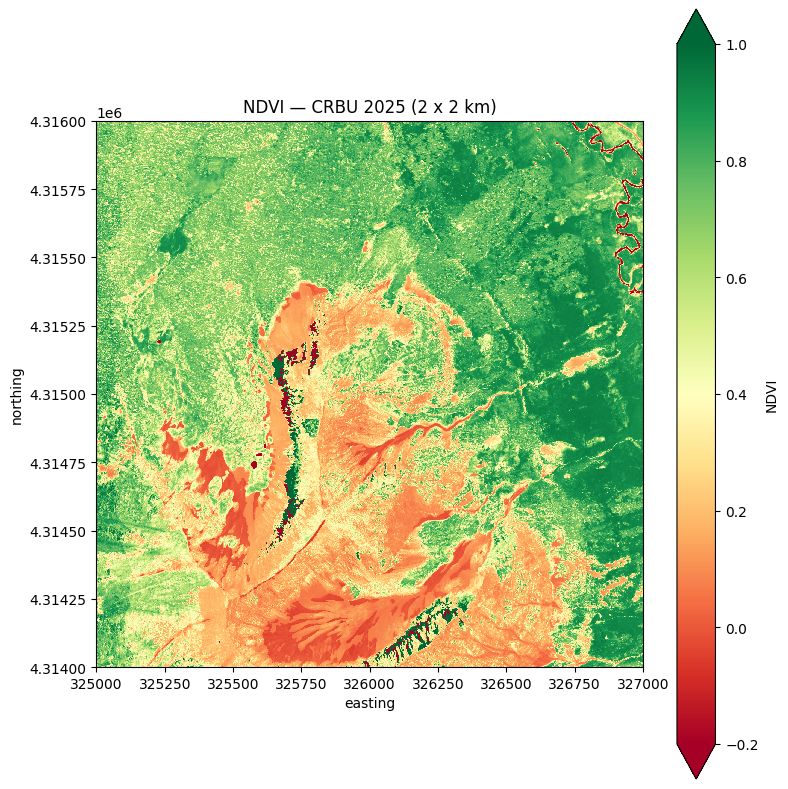

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
ndvi_result.plot(
    ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=1.0, robust=True,
    cbar_kwargs={"label": "NDVI"},
)
ax.set_title("NDVI — CRBU 2025 (2 x 2 km)")
ax.set_aspect("equal")
plt.tight_layout()

## 5. Reduce First, Compute Later: Study Plot Spectra

When you don't need the full spatial result, reduce the data *before*
computing. This is much faster because Dask can reduce each chunk
independently and only transfer the small aggregated results.

Example: extract mean reflectance spectra for 10 randomly placed
100 x 100 m study plots within the 2 x 2 km region. Each plot's mean
spectrum is built as a lazy reduction, then all 10 are computed in a
single parallel batch with `dask.compute()`.

CPU times: user 11.2 s, sys: 2.71 s, total: 13.9 s
Wall time: 2min 16s


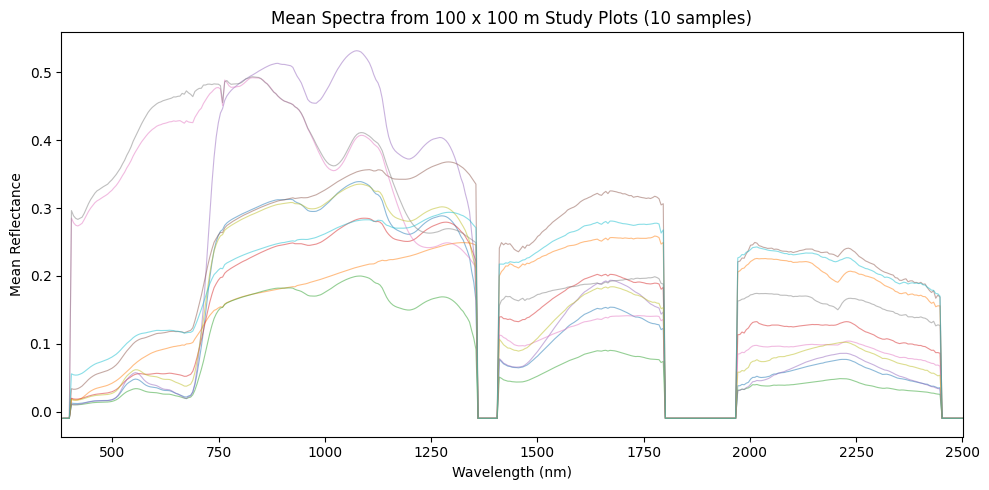

In [7]:
%%time
import dask

# Mask no-data (lazy)
region_masked = region.where(region > -9000)

# Define the grid of possible 100 m plot origins within the 2x2 km region
northing_vals = region_masked.northing.values
easting_vals = region_masked.easting.values
north_starts = northing_vals[::100]  # every 100 m
east_starts = easting_vals[::100]

# Randomly select 10 plot locations
rng = np.random.default_rng(42)
n_plots = 10
ni = rng.choice(len(north_starts), size=n_plots, replace=False)
ei = rng.choice(len(east_starts), size=n_plots, replace=False)

# Build lazy mean spectra for each 100 x 100 m patch
lazy_spectra = []
for n_idx, e_idx in zip(ni, ei):
    n0 = north_starts[n_idx]
    e0 = east_starts[e_idx]
    patch = region_masked.sel(
        northing=slice(n0, n0 - 99),   # northing is decreasing
        easting=slice(e0, e0 + 99),
    )
    lazy_spectra.append(patch.mean(dim=["northing", "easting"]))

# Single parallel compute for all 10 patches
spectra_results = dask.compute(*lazy_spectra)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for spec in spectra_results:
    vals = spec.values
    if not np.all(np.isnan(vals)):
        ax.plot(ds.wavelength.values, vals, alpha=0.5, linewidth=0.8)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean Reflectance")
ax.set_title(f"Mean Spectra from 100 x 100 m Study Plots ({n_plots} samples)")
ax.set_xlim(380, 2500)
plt.tight_layout()

## 6. Band Math Across the Full Mosaic

Dask makes it practical to compute derived products across the entire
mosaic. The key is to keep everything lazy until the final reduction.

Example: compute NDVI across the full CRBU 2025 domain and aggregate
to 3 m resolution. This reduces the output from 30,000 x 22,000 pixels
to ~10,000 x 7,333 pixels while processing the full 1 TB+ dataset.

In [ ]:
%%time
# Work on the full mosaic
red_full = ds.reflectance.sel(wavelength=660, method="nearest")
nir_full = ds.reflectance.sel(wavelength=850, method="nearest")

red_full = red_full.where(red_full > -9000)
nir_full = nir_full.where(nir_full > -9000)

ndvi_full = (nir_full - red_full) / (nir_full + red_full)

# Aggregate to 3 m resolution (3x3 pixel blocks)
ndvi_3m = ndvi_full.coarsen(
    northing=3, easting=3, boundary="trim"
).mean()

# Now compute -- this processes the full mosaic in parallel
ndvi_3m_result = ndvi_3m.compute()
print(f"Result shape: {ndvi_3m_result.shape} (3 m resolution)")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 12))
ndvi_3m_result.plot(
    ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=1.0, robust=True,
    cbar_kwargs={"label": "NDVI (3 m)"},
)
ax.set_title("NDVI at 3 m Resolution — CRBU 2025 (Full Mosaic)")
ax.set_aspect("equal")
plt.tight_layout()

## 7. Saving Results

Save derived products as NetCDF, Zarr, or GeoTIFF. Use
[rioxarray](https://corteva.github.io/rioxarray/) to export
georeferenced GeoTIFFs that can be opened in QGIS, ArcGIS, or Google
Earth Engine.

In [ ]:
import rioxarray  # extends xarray with .rio accessor

# --- NetCDF ---
ndvi_3m_result.to_netcdf("crbu_2025_ndvi_3m.nc")
print("Saved to crbu_2025_ndvi_3m.nc")

# --- GeoTIFF ---
# Assign the CRS and spatial dimensions so rioxarray knows the georeferencing
ndvi_3m_result.rio.set_spatial_dims(x_dim="easting", y_dim="northing", inplace=True)
ndvi_3m_result.rio.write_crs("EPSG:32613", inplace=True)
ndvi_3m_result.rio.to_raster("crbu_2025_ndvi_3m.tif")
print("Saved to crbu_2025_ndvi_3m.tif")

# --- Zarr (best for large results you'll re-open in Python) ---
# ndvi_3m_result.to_zarr("crbu_2025_ndvi_3m.zarr", mode="w")

## 8. Performance Tips

### Choose the right server profile

| Task | Recommended Profile |
|------|--------------------|
| Exploring a few tiles | Small (2 CPU / 8 GB) |
| Processing 10-50 tiles | Medium (4 CPU / 16 GB) |
| Full-mosaic analysis | Large (8 CPU / 32 GB) or XLarge (32 CPU / 64 GB) |

### Tune Dask workers

Match `n_workers` and `memory_limit` to your profile:

```python
# Small profile
client = Client(n_workers=2, threads_per_worker=1, memory_limit="3GB")

# Medium profile
client = Client(n_workers=4, threads_per_worker=2, memory_limit="3GB")

# Large profile
client = Client(n_workers=8, threads_per_worker=2, memory_limit="3GB")

# XLarge profile
client = Client(n_workers=16, threads_per_worker=2, memory_limit="3GB")
```

### Reduce before computing

Always apply spatial/spectral reductions (mean, max, count) *before*
calling `.compute()`. This minimizes the amount of data that needs to
be held in memory.

### Subset spatially first

Use `.sel()` to clip to your study area before doing any band math.
Processing the full 30,000 x 22,000 mosaic is much slower than a
targeted 5,000 x 5,000 subset.

### Watch the Dask dashboard

The dashboard URL is printed when you create the client. It shows:
- **Task Stream**: which chunks are being processed
- **Memory**: per-worker memory usage
- **Progress**: overall completion

If you see workers spilling to disk or running out of memory, reduce
`memory_limit` or increase `n_workers` (more workers with less memory each).

In [ ]:
# Clean up
client.close()